# Librerías

In [57]:
# ==============================
# IMPORTACIÓN DE LIBRERÍAS NLP
# ==============================

import nltk   # Librería principal para procesamiento de lenguaje natural
import re   # Librería para trabajar con expresiones regulares (limpieza de texto)
import string   # Contiene constantes útiles como signos de puntuación
import matplotlib.pyplot as plt   # Librería para graficar resultados (frecuencias, histogramas, etc.)

# ==============================
# MÓDULOS ESPECÍFICOS DE NLTK
# ==============================
from nltk.tokenize import word_tokenize   # Función para dividir texto en palabras (tokenización)
from nltk.corpus import stopwords  # Lista de palabras vacías (stopwords) como: "el", "la", "y", etc.
# Algoritmo de stemming (reduce palabras a su raíz)
# Ejemplo: "corriendo" → "corr"
from nltk.stem import SnowballStemmer  

# ==============================
# OTRAS HERRAMIENTAS ÚTILES
# ==============================

# Estructura para contar frecuencia de elementos (palabras)
# Ejemplo: contar cuántas veces aparece cada palabra
from collections import Counter  



# ==============================
# DESCARGAS NECESARIAS (SOLO UNA VEZ)
# ==============================

#nltk.download('punkt_tab')       # Para tokenización
#nltk.download('stopwords')  # Para palabras vacías
#nltk.download('wordnet')
#nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

Crear función para conservar los emojis

In [4]:
def reemplazar_emojis(texto):
    """
    Convierte emojis comunes en etiquetas de texto descriptivas.

    Esta transformación es útil porque:
    1. Preserva la carga emocional o semántica del mensaje.
    2. Evita la pérdida de información relevante, especialmente en tareas
       como análisis de sentimientos.
    3. Facilita el procesamiento posterior, al representar los emojis
       como tokens de texto estándar.
    """
    mapa_emojis =  {
    # 😊 Emociones positivas
    "😀": "feliz",
    "😃": "feliz",
    "😄": "feliz",
    "😁": "feliz",
    "🙂": "feliz",
    "😊": "feliz",
    "😍": "amor",
    "🥰": "amor",
    "😘": "beso",
    "❤️": "amor",
    "💖": "amor",
    "💕": "amor",
    "💘": "amor",
    "✨": "positivo",
    "🔥": "excelente",
    "👏": "aplauso",
    "👍": "aprobacion",

    # 😂 Humor / risa
    "😂": "risa",
    "🤣": "risa",
    "😆": "risa",
    "😹": "risa",

    # 😐 Emociones neutrales
    "😐": "neutral",
    "😑": "neutral",
    "😶": "silencio",
    "🤔": "pensando",

    # 😢 Emociones negativas
    "😢": "triste",
    "😭": "triste",
    "☹️": "triste",
    "🙁": "triste",
    "😞": "triste",
    "😔": "triste",
    "😡": "enojo",
    "😠": "enojo",
    "🤬": "enojo",
    "😤": "frustracion",
    "💔": "desamor",

    # 😨 Miedo / sorpresa
    "😱": "sorpresa",
    "😨": "miedo",
    "😰": "ansiedad",
    "😳": "sorpresa",

    # 🤢 Rechazo
    "🤢": "asco",
    "🤮": "asco",

    # 😴 Estados físicos
    "😴": "sueño",
    "🥱": "cansancio",

    # 🙏 Gestos
    "🙏": "agradecimiento",
    "🙌": "celebracion",
    "💪": "fuerza",

    # 🚀 Objetos / contexto positivo
    "🚀": "exito",
    "🎉": "celebracion",
    "🏆": "logro",}

    for emoji, etiqueta in mapa_emojis_.items():
        texto = texto.replace(emoji, etiqueta)
    return texto

In [5]:
def reemplazar_emojis(texto):
    """
    Convierte ciertos emojis frecuentes en etiquetas de texto.

    Esto es útil porque:
    1. Conserva parte de la carga emocional o semantica.
    2. Evita perder informacion importante en tareas como analisis de sentimientos.
    3. Facilita el procesamiento posterior, porque el emoji se vuelve texto.
    """

    mapa_emojis = {
        "😡": "emoji_enojo",
        "😀": "emoji_felicidad",
        "😍": "emoji_amor",
        "🍕": "emoji_pizza"
    }

    for emoji, etiqueta in mapa_emojis.items():
        texto = texto.replace(emoji, etiqueta)

    return texto


<b>¡Pésimo servicio </b> 😡 La comida llegó tarde. <br> Visiten htttp://quejas.com. Costó 250 pesos,

In [7]:
texto_web = "<b>¡Pésimo servicio!</b> 😡 La comida llegó tarde. <br> Visiten http://quejas.com. Costó 250 pesos. &&"
print(f"Texto original: {texto_web}")

Texto original: <b>¡Pésimo servicio!</b> 😡 La comida llegó tarde. <br> Visiten http://quejas.com. Costó 250 pesos. &&


# Limpieza básica

**Paso 1: Quitar etiquetas HTML (NLP)**

En este paso se eliminan etiquetas HTML como `<b>`, `<p>`, `<div>`, etc., para quedarnos únicamente con el contenido textual.

**¿Por qué es importante en NLP?**
- Los modelos trabajan con texto limpio, no con estructura HTML.
- Las etiquetas pueden introducir ruido y afectar la tokenización.
- Mejora la calidad de características (features) en tareas como:
  - análisis de sentimientos
  - clasificación de texto
  - modelos de lenguaje

**Nota importante:**
- No siempre se deben eliminar.
- En algunos casos pueden aportar información útil (por ejemplo, `<title>`, `<h1>`).
- La decisión depende del objetivo del modelo y del dataset.

In [10]:
texto_sin_html = re.sub(r'<.*?>', '', texto_web)
texto_sin_html

'¡Pésimo servicio! 😡 La comida llegó tarde.  Visiten http://quejas.com. Costó 250 pesos. &&'

**Paso $2$: Quitar URLs (NLP)**

En este paso se eliminan enlaces o URLs como `http://...`, `https://...` o `www...` del texto.

**¿Por qué es importante en NLP?**
- Las URLs no aportan significado lingüístico relevante.
- Introducen ruido en el modelo (cadenas largas sin semántica clara).
- Pueden afectar procesos como:
  - tokenización
  - conteo de palabras
  - generación de embeddings

**Nota importante:**
- En la mayoría de tareas (sentimientos, clasificación) se eliminan.
- Sin embargo, en algunos casos pueden ser útiles:
  - detección de spam
  - análisis de fuentes o dominios
- En esos casos, se pueden reemplazar por una etiqueta como `URL`.

In [12]:
# Eliminar URLs (http, https, www)
texto_sin_urls = re.sub(r'https?://\S+|www\.\S+', '', texto_sin_html)
texto_sin_urls

'¡Pésimo servicio! 😡 La comida llegó tarde.  Visiten  Costó 250 pesos. &&'

**Paso $3$: Convertir texto a minúsculas (NLP)**

En este paso se transforma todo el texto a minúsculas.

**¿Por qué es importante en NLP?**
- Evita duplicados innecesarios: "Hola" y "hola" se consideran la misma palabra.
- Reduce el tamaño del vocabulario.
- Mejora la consistencia en procesos como:
  - tokenización
  - conteo de frecuencias
  - modelos de lenguaje

**Ejemplo:**
- "Excelente Servicio" → "excelente servicio"

**Nota importante:**
- No siempre se debe aplicar.
- Puede ser útil conservar mayúsculas cuando:
  - se analizan nombres propios
  - se detectan entidades (NER)
  - se estudia énfasis o emociones (ej: "NO ME GUSTÓ")

In [14]:
texto_minusculas = texto_sin_urls.lower()
texto_minusculas

'¡pésimo servicio! 😡 la comida llegó tarde.  visiten  costó 250 pesos. &&'

**Paso $4$: Convertir emojis a etiquetas textuales (NLP)**

En este paso se transforman los emojis en etiquetas de texto utilizando una función personalizada (por ejemplo, `reemplazar_emojis`).

**¿Por qué es importante en NLP?**
- Los modelos de texto no interpretan emojis directamente.
- Permite conservar la información emocional o contextual del mensaje.
- Evita perder señales importantes en tareas como:
  - análisis de sentimientos
  - clasificación de texto
  - minería de opiniones

**Ejemplo:**
- "¡Me encantó 😍!" → "¡Me encantó emoji_amor!"

**Ventajas:**
- Estandariza la representación de emociones.
- Facilita el procesamiento posterior (tokenización, conteo, embeddings).
- Reduce la ambigüedad de los símbolos.

**Nota importante:**
- El rendimiento depende del diccionario de emojis definido.
- Se puede ampliar según el dominio del problema.
- En algunos casos, se pueden agrupar emojis por categorías (positivo, negativo, neutral).

In [16]:
texto_con_emojis = reemplazar_emojis(texto_minusculas)
texto_con_emojis

'¡pésimo servicio! emoji_enojo la comida llegó tarde.  visiten  costó 250 pesos. &&'

**Paso $5$: Quitar símbolos raros (NLP)**

En este paso se eliminan caracteres especiales o símbolos poco comunes que no aportan significado al texto.

Se conservan únicamente:
- letras (a–z, incluyendo caracteres propios del español como ñ, á, é, í, ó, ú)
- números
- espacios
- algunos signos de puntuación básicos (según el caso)

**¿Por qué es importante en NLP?**
- Reduce el ruido en los datos.
- Mejora la calidad de la tokenización.
- Evita que el modelo aprenda patrones irrelevantes.
- Facilita el análisis de texto y la construcción de
  to es increíble"

**Nota importante:**
- No siempre se deben eliminar todos los símbolos.
- Algunos pueden ser útiles dependiendo del problema:
  - "!" → puede indicar emoción
  - "?" → puede indicar pregunta
  - "#" → útil en análisis de redes sociales (hashtags)
- La limpieza debe adaptarse al objetivo del modelo.

In [18]:
# Elimina símbolos no deseados del texto
# [^\w\sáéíóúüñ¡!¿?.,] significa:
# ^        → negación (todo lo que NO esté en el conjunto)
# \w       → letras y números (incluye _)
# \s       → espacios
# áéíóúüñ  → caracteres propios del español
# ¡!¿?.,   → signos de puntuación que queremos conservar
#
# Todo lo que NO cumpla con lo anterior se reemplaza por un espacio

texto_limpio_parcial = re.sub('[^\w\sáéíóúüñ¡!¿?.,]', ' ', texto_con_emojis)

# Resultado: texto más limpio, sin símbolos raros
texto_limpio_parcial

'¡pésimo servicio! emoji_enojo la comida llegó tarde.  visiten  costó 250 pesos.   '

# Normalización

**Paso 6: Manejo de puntuación (NLP)**

En este paso se procesan los signos de puntuación como `. , ! ? ; :` dentro del texto.

**¿Por qué es importante en NLP?**
- La puntuación puede afectar la tokenización.
- Puede introducir ruido si no se maneja correctamente.
- Influye en el significado y tono del texto.

**Opciones comunes:**
1. **Eliminar puntuación**
   - Útil en modelos simples (Bag of Words, TF-IDF).
   - Ejemplo: "Hola, ¿cómo estás?" → "Hola cómo estás"

2. **Conservar puntuación**
   - Útil cuando aporta información semántica.
   - Ejemplo:
     - "!" → emoción
     - "?" → pregunta

3. **Reemplazar por espacios**
   - Facilita la separación de palabras.

**Ejemplo:**
- "¡Excelente servicio!" → "Excelente servicio"
- "¿Qué pasó?" → "Qué pasó"

**Nota importante:**
- La decisión depende del modelo y la tarea:
  - análisis de sentimientos → puede ser útil conservar "!"
  - clasificación general → suele eliminarse
- En modelos avanzados (como transformers), muchas veces no es necesario eliminarla completamente.

In [38]:
# ==============================
# ELIMINAR SIGNOS DE PUNTUACIÓN
# ==============================

# Se utiliza el método translate() para eliminar caracteres específicos del texto.
# str.maketrans('', '', caracteres) crea una tabla de traducción donde:
# - '' (primer argumento) → no se reemplaza nada
# - '' (segundo argumento) → no se sustituye ningún carácter
# - caracteres (tercer argumento) → se eliminan del texto

# string.punctuation incluye signos como: . , ! ? ; : etc.
# Se agregan manualmente '¡¿' porque no vienen incluidos por defecto  y son comunes en español

texto_sin_puntuacion = texto_limpio_parcial.translate(
    str.maketrans('', '', string.punctuation + '¡¿')
)

# Resultado:
# Texto limpio sin signos de puntuación, lo que facilita
# tareas como tokenización, conteo de palabras y modelos NLP

texto_sin_puntuacion

'pésimo servicio emojienojo la comida llegó tarde  visiten  costó 250 pesos   '

**Paso 7: Quitar números (NLP)**

En este paso se eliminan los números del texto.

**¿Por qué es importante en NLP?**
- Los números muchas veces no aportan significado semántico relevante.
- Reducen el tamaño del vocabulario.
- Evitan ruido en tareas como:
  - análisis de sentimientos
  - clasificación de texto
  - modelos de lenguaje

**Ejemplo:**
- "El producto costó 250 pesos" → "El producto costó pesos"

**Nota importante:**
- No siempre se deben eliminar.
- Pueden ser útiles en ciertos casos:
  - análisis financiero (precios, cantidades)
  - fechas (2024, 15/03)
  - métricas (porcentajes, ratings)
- La decisión depende del problema y del dataset.

In [43]:
texto_sin_numeros = re.sub(r'\d+', '', texto_sin_puntuacion)
texto_sin_numeros

'pésimo servicio emojienojo la comida llegó tarde  visiten  costó  pesos   '

**Paso $8$: Quitar espacios extra (NLP)**

En este paso se eliminan los espacios innecesarios dentro del texto, como múltiples espacios consecutivos o espacios al inicio y al final.

**¿Por qué es importante en NLP?**
- Evita inconsistencias en el texto.
- Mejora la calidad de la tokenización.
- Facilita el procesamiento posterior.
- Reduce errores en conteo de palabras y análisis.

**Ejemplo:**
- "Hola    mundo   " → "Hola mundo"

**¿Qué se hace exactamente?**
- Reemplazar múltiples espacios por uno solo.
- Eliminar espacios al inicio y al final del texto.

**Nota importante:**
- Es un paso final de limpieza.
- Generalmente se aplica después de eliminar:
  - URLs
  - símbolos
  - números
  - puntuación

In [46]:
# Reemplaza múltiples espacios por uno solo
texto_limpio_final = re.sub(r'\s+', ' ', texto_sin_numeros)
texto_limpio_final 

'pésimo servicio emojienojo la comida llegó tarde visiten costó pesos '

**Paso $9$: Tokenización (NLP)**

En este paso se divide el texto en unidades más pequeñas llamadas **tokens**.

Un token puede ser:
- una palabra
- un número
- un signo de puntuación (según el caso)

**¿Por qué es importante en NLP?**
- Es el primer paso para analizar texto.
- Permite transformar texto en datos que los modelos pueden procesar.
- Facilita tareas como:
  - conteo de palabras
  - eliminación de stopwords
  - stemming o lematización
  - generación de embeddings

**Ejemplo:**
- Texto: "El servicio fue excelente"
- Tokens: ["El", "servicio", "fue", "excelente"]

**Tipos de tokenización:**
- Por palabras → la más común
- Por oraciones → dividir en frases
- Por caracteres → usado en modelos avanzados

**Nota importante:**
- La calidad de la tokenización afecta todo el pipeline.
- Idiomas como el español requieren manejar:
  - acentos
  - signos como ¿ ? ¡ !
- Se recomienda usar herramientas como `nltk.word_tokenize`.

In [61]:
tokens = word_tokenize(texto_limpio_final, language = 'spanish')
tokens

['pésimo',
 'servicio',
 'emojienojo',
 'la',
 'comida',
 'llegó',
 'tarde',
 'visiten',
 'costó',
 'pesos']

**Paso $10$: Eliminar stopwords (NLP)**

En este paso se eliminan las **stopwords**, que son palabras muy frecuentes en un idioma pero que aportan poco significado al texto.

Ejemplos en español:
- "el", "la", "de", "y", "en", "que", "por"

**¿Por qué es importante en NLP?**
- Reduce el ruido en los datos.
- Disminuye el tamaño del vocabulario.
- Mejora la eficiencia de los modelos.
- Permite enfocarse en palabras con mayor carga semántica.

**Ejemplo:**
- Texto: "El servicio de la comida fue excelente"
- Sin stopwords: "servicio comida excelente"

**Nota importante:**
- No siempre se deben eliminar.
- Pueden ser útiles en ciertos casos:
  - análisis gramatical
  - modelos de lenguaje avanzados (como BERT)
  - detección de negaciones ("no", "nunca")

**Recomendación:**
- Revisar la lista de stopwords y adaptarla según el problema.

In [89]:
# Obtener stopwords en español
# Cargmos las stopwords en español.
# Las stopwords son palabras muy frecuentes que en muchos casos no aportan demasiado significado temático
stop_words = set(stopwords.words('spanish'))
list(stop_words)[:10]

['estadas',
 'hubisteis',
 'de',
 'seríais',
 'tendrán',
 'fueron',
 'estabais',
 'ya',
 'habré',
 'hubieses']

In [91]:
# En el anális de sentimientos conviene conservar algunas negaciones porque cambian completamente el significado 
# Definir negaciones que NO queremos eliminar
negaciones = {"no", "nunca", "ni"}

# Quitar las negaciones del conjunto de stopwords
stop_words = stop_words - negaciones

# Filtrar tokens conservando negaciones
tokens_filtrados = [t for t in tokens if t.lower() not in stop_words]

tokens_filtrados

['pésimo',
 'servicio',
 'emojienojo',
 'comida',
 'llegó',
 'tarde',
 'visiten',
 'costó',
 'pesos']

**Paso 11: Stemming (NLP)**

En este paso se aplica **stemming**, un proceso que reduce las palabras a su raíz o forma base (stem), eliminando sufijos y terminaciones.

**¿Por qué es importante en NLP?**
- Reduce la variabilidad del lenguaje.
- Disminuye el tamaño del vocabulario.
- Agrupa palabras con formas similares.
- Mejora el rendimiento en modelos como:
  - Bag of Words
  - TF-IDF
  - clasificación de texto

**Ejemplo:**
- "corriendo", "corre", "corrió" → "corr"

**Ventajas:**
- Rápido y eficiente.
- Fácil de implementar.
- Útil en grandes volúmenes de texto.

**Desventajas:**
- Puede generar palabras que no existen.
- No considera el significado (semántica).
- Puede agrupar palabras incorrectamente.

**Nota importante:**
- Es recomendable usarlo en modelos simples.
- Para tareas donde el significado es clave, es mejor usar lematización.

**Herramienta común en Python:**
- `SnowballStemmer` (soporte para español)

In [96]:
stemmer = SnowballStemmer('spanish')
stemmer 

In [100]:
# Aplicar stemming a los tokens
tokens_stem = [stemmer.stem(t) for t in tokens_filtrados]
tokens_stem

['pesim',
 'servici',
 'emojienoj',
 'com',
 'lleg',
 'tard',
 'visit',
 'cost',
 'pes']

In [104]:
# Mostraremos un pequeño resumen estadístico de una lista de tokens

def resumen_tokens(lista_tokens, nombre):
    """
    Parametros:
    lista_tokens: lista de palabras
    nombre: titulo del resumen
    """

    print(f"\n{nombre}")
    print("Cantidad total de tokens:", len(lista_tokens))
    print("Vocabulario único:", len(set(lista_tokens)))
    print("Top 5 palabras:", Counter(lista_tokens).most_common(5))


resumen_tokens(tokens, "Antes de quitar stopwords")

resumen_tokens(tokens_filtrados, "Despues de quitar stopwords")


Antes de quitar stopwords
Cantidad total de tokens: 10
Vocabulario único: 10
Top 5 palabras: [('pésimo', 1), ('servicio', 1), ('emojienojo', 1), ('la', 1), ('comida', 1)]

Despues de quitar stopwords
Cantidad total de tokens: 9
Vocabulario único: 9
Top 5 palabras: [('pésimo', 1), ('servicio', 1), ('emojienojo', 1), ('comida', 1), ('llegó', 1)]


In [106]:
texto_prueba =  """ 
El perro corre rápido, el perro salta alto.
La gata corre con el perro.
El perro es feliz.
Pero las natas no quiere jugar
"""

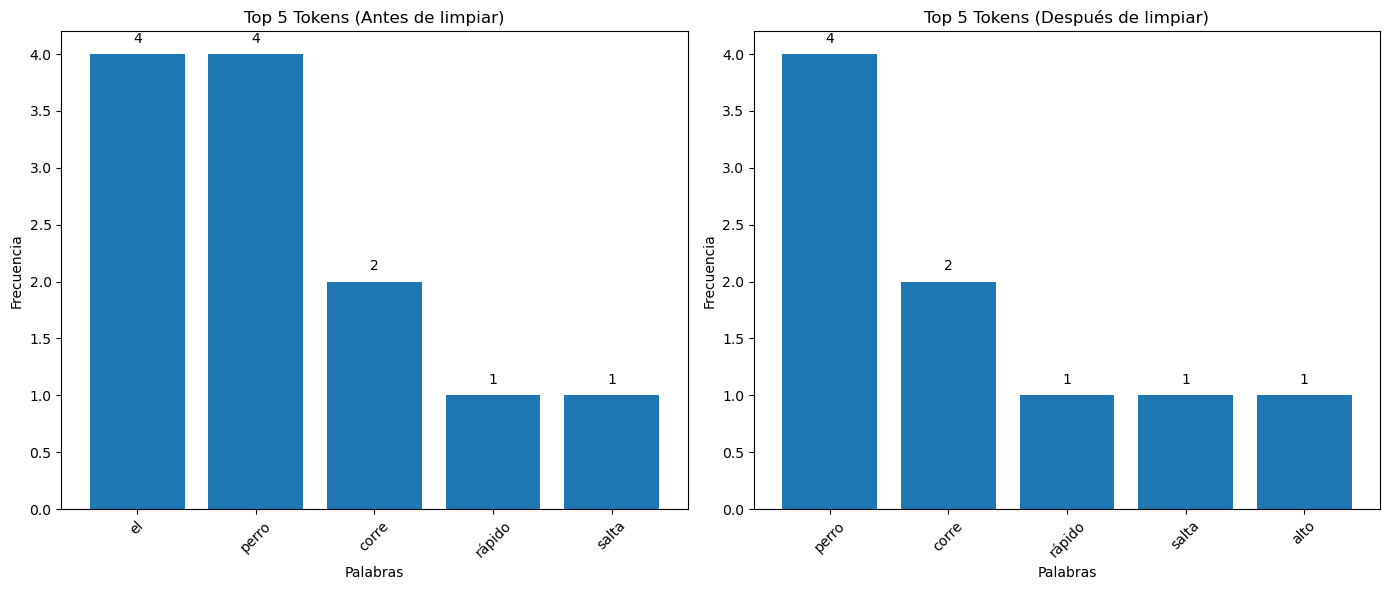

In [112]:
# Tokenización
tokens_sucios = word_tokenize(texto_prueba.lower(), language='spanish')

# Solo palabras (sin números ni símbolos)
tokens_sucios = [t for t in tokens_sucios if t.isalpha()]

# Quitar stopwords
tokens_limpios = [t for t in tokens_sucios if t not in stop_words]

# Top 5
top_sucios = Counter(tokens_sucios).most_common(5)
top_limpios = Counter(tokens_limpios).most_common(5)

# Separar palabras y frecuencias
pal_sucias, freq_sucias = zip(*top_sucios)
pal_limpias, freq_limpias = zip(*top_limpios)

# ==============================
# GRÁFICOS MEJORADOS
# ==============================

plt.figure(figsize=(14,6))

# Gráfico 1: Tokens sucios
plt.subplot(1,2,1)
plt.bar(pal_sucias, freq_sucias)
plt.title("Top 5 Tokens (Antes de limpiar)", fontsize=12)
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)

# Mostrar valores encima de las barras
for i, v in enumerate(freq_sucias):
    plt.text(i, v + 0.1, str(v), ha='center')

# Gráfico 2: Tokens limpios
plt.subplot(1,2,2)
plt.bar(pal_limpias, freq_limpias)
plt.title("Top 5 Tokens (Después de limpiar)", fontsize=12)
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)

# Mostrar valores encima de las barras
for i, v in enumerate(freq_limpias):
    plt.text(i, v + 0.1, str(v), ha='center')

# Ajustar espacios
plt.tight_layout()

plt.show()

In [114]:
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer

# Inicializar herramientas
stemmer = SnowballStemmer("spanish")
lemmatizer = WordNetLemmatizer()

# Palabras de prueba (mezcla español + inglés para ver diferencias reales)
palabras = [
    "corriendo", "corre", "corrió",   # verbos en español
    "mejor", "peor",                 # comparativos
    "running", "ran", "better", "worse"  # inglés (para lematización real)
]

print("=== STEMMING (reduce a raíz, puede no ser palabra real) ===")
for p in palabras:
    print(f"{p:10} → {stemmer.stem(p)}")

print("\n=== LEMATIZACIÓN (forma base real, depende del idioma) ===")
for p in palabras:
    print(f"{p:10} → {lemmatizer.lemmatize(p)}")

=== STEMMING (reduce a raíz, puede no ser palabra real) ===
corriendo  → corr
corre      → corr
corrió     → corr
mejor      → mejor
peor       → peor
running    → running
ran        → ran
better     → bett
worse      → wors

=== LEMATIZACIÓN (forma base real, depende del idioma) ===
corriendo  → corriendo
corre      → corre
corrió     → corrió
mejor      → mejor
peor       → peor
running    → running
ran        → ran
better     → better
worse      → worse
